In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!pip install ultralytics

# 2. Unzip your data
!unzip -q '/content/drive/MyDrive/VisDrone_Project/visdrone_data.zip' -d '/content/'

# 3. Verify
import os
print(os.listdir('/content/yolo_dataset_v2'))

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 28.3 MB/s eta 0:00:00
unzip:  cannot find or open /content/drive/MyDrive/VisDrone_Project/visdrone_data.zip, /content/drive/MyDrive/VisDrone_Project/visdrone_data.zip.zip or /content/drive/MyDrive/VisDrone_Project/visdrone_data.zip.ZIP.


FileNotFoundError: [Errno 2] No such file or directory: '/content/yolo_dataset_v2'

In [ ]:
!find /content/drive/MyDrive/ -name "yolo_dataset_v2.zip"


!unzip -q "/content/drive/MyDrive/VisDrone_Project/visdrone_data.zip" -d "/content/"

In [ ]:
!pip install ultralytics


In [ ]:
import yaml

#  to find the images we just unzipped
data_config = {
    'train': '/content/yolo_dataset_v2/images/train',
    'val': '/content/yolo_dataset_v2/images/val',
    'nc': 1,
    'names': ['Human']
}

with open('/content/coco_custom.yaml', 'w') as f:
    yaml.dump(data_config, f)

print("SUCCESS: Map (coco_custom.yaml) is ready!")

SUCCESS: Map (coco_custom.yaml) is ready!


In [ ]:
from ultralytics import YOLO
model = YOLO('yolov8n.pt')

#TRAIN
results = model.train(
    data='/content/coco_custom.yaml',
    epochs=25,       # Total rounds of learning
    imgsz=640,       # Image size
    device=0,        # T4 GPU
    plots=True       # Charts
)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.50 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/coco_custom.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=25, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=64

In [ ]:
!cp /content/runs/detect/train/weights/best.pt /content/drive/MyDrive/VisDrone_Project/human_detection_v2.pt
print("Success! Your AI brain is safely saved to your Google Drive.")

Success! Your AI brain is safely saved to your Google Drive.


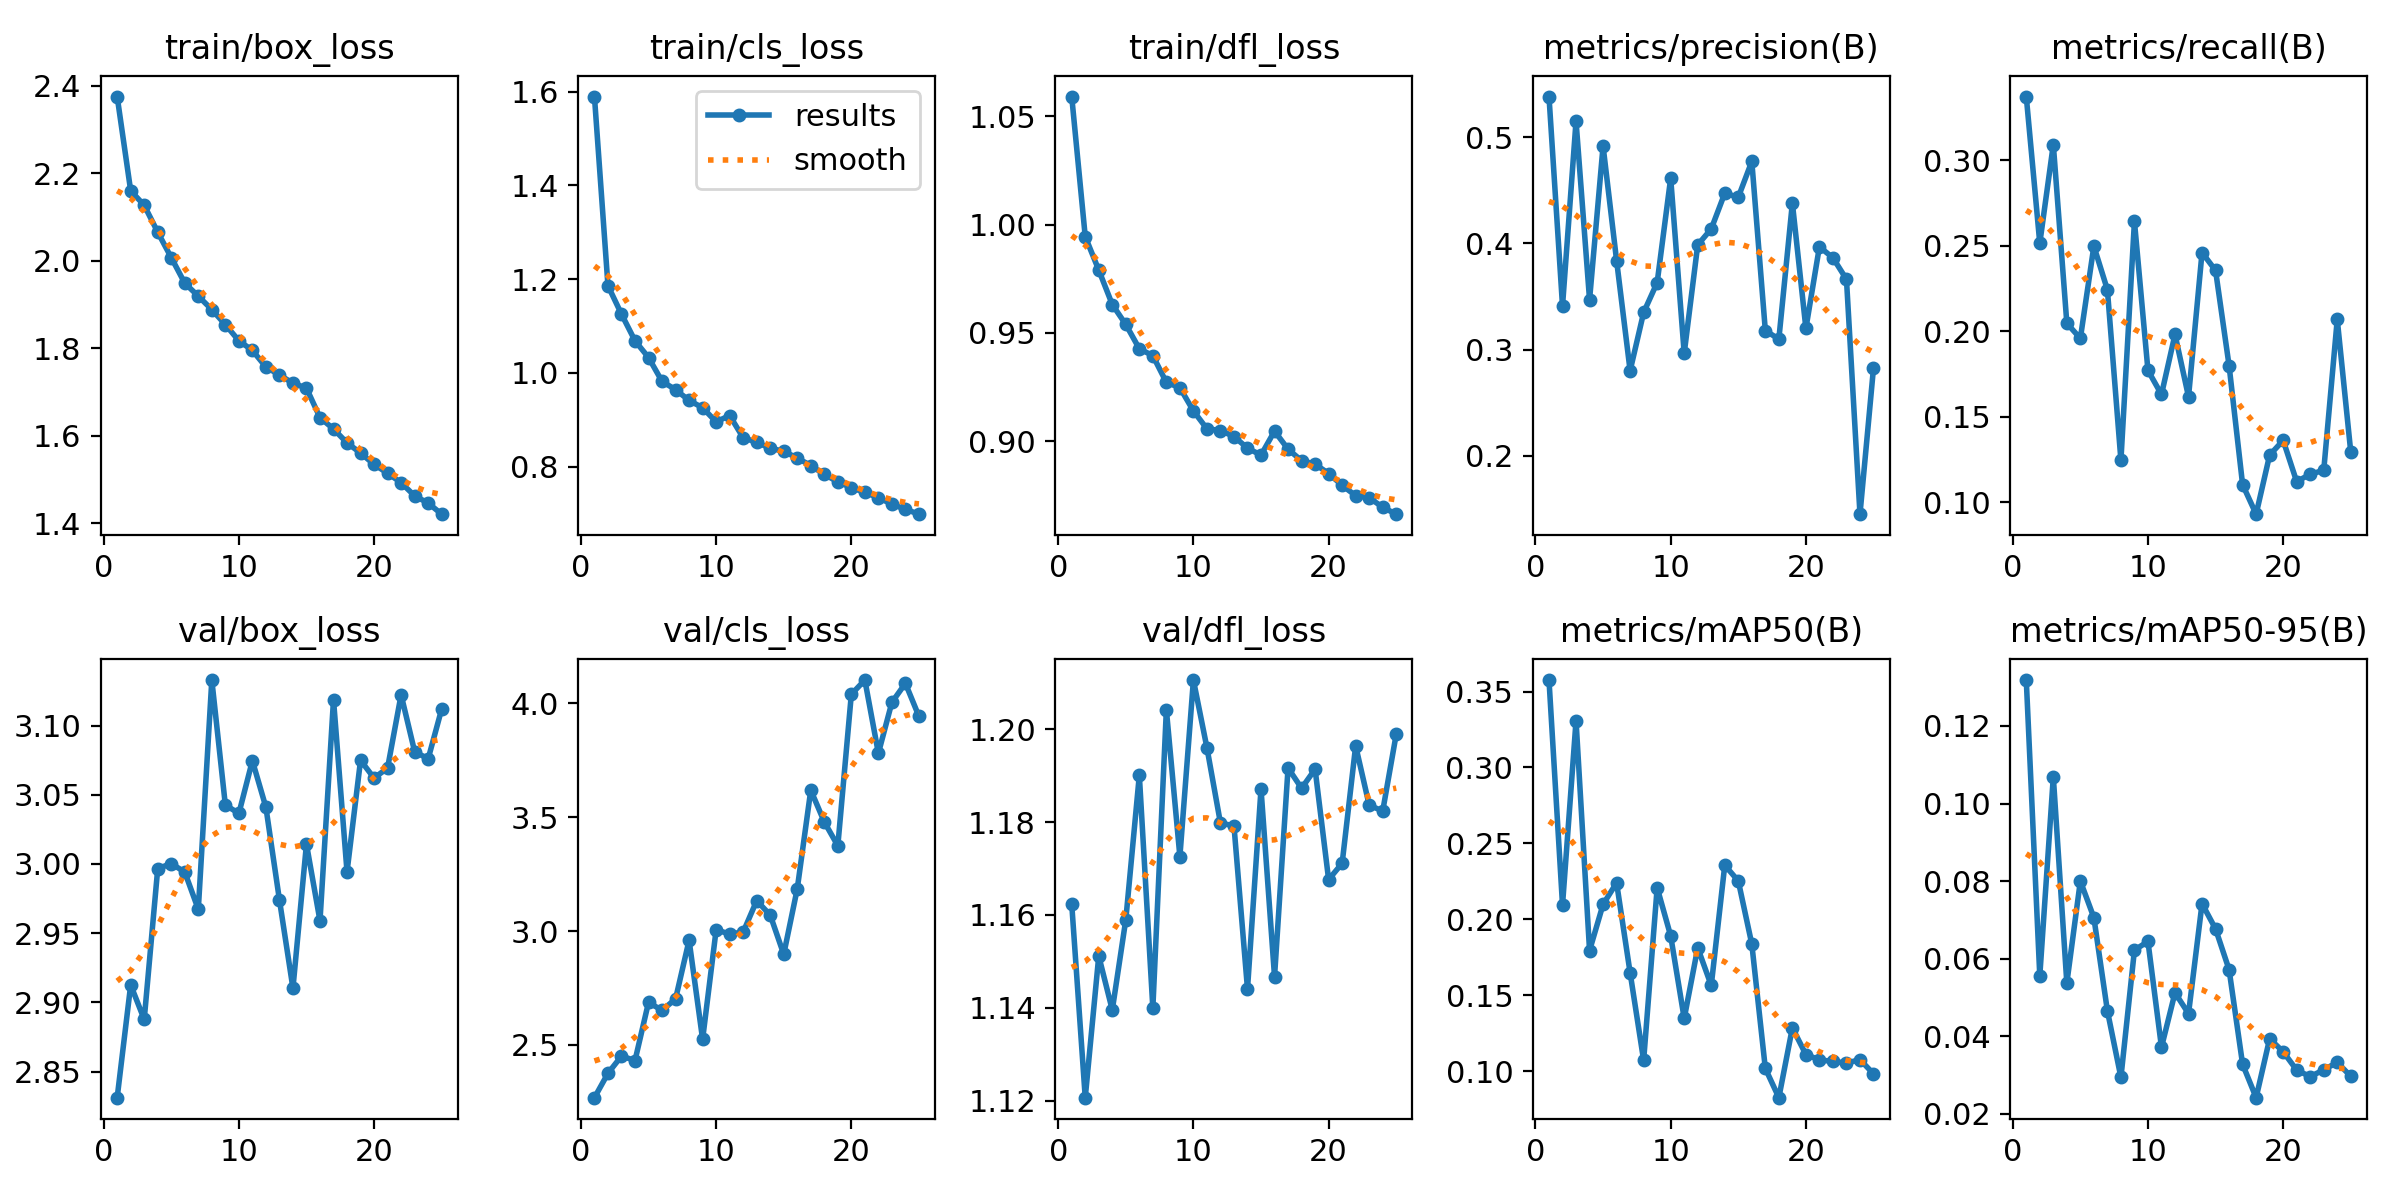

In [ ]:
from IPython.display import Image
Image(filename='/content/runs/detect/train/results.png', width=1000)

In [ ]:
# This runs 'inference' on a test image
!yolo predict model=/content/runs/detect/train/weights/best.pt source='/content/yolo_dataset_v2/images/val' save=True imgsz=640 conf=0.25 line_width=2

# To see the result, find the image in: /content/runs/detect/predict/

Ultralytics 8.4.50 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs

image 1/1421 /content/yolo_dataset_v2/images/val/uav0000009_03358_v_0000001.jpg: 384x640 (no detections), 46.4ms
image 2/1421 /content/yolo_dataset_v2/images/val/uav0000009_03358_v_0000002.jpg: 384x640 (no detections), 6.4ms
image 3/1421 /content/yolo_dataset_v2/images/val/uav0000009_03358_v_0000003.jpg: 384x640 (no detections), 5.8ms
image 4/1421 /content/yolo_dataset_v2/images/val/uav0000009_03358_v_0000004.jpg: 384x640 (no detections), 6.3ms
image 5/1421 /content/yolo_dataset_v2/images/val/uav0000009_03358_v_0000005.jpg: 384x640 (no detections), 6.4ms
image 6/1421 /content/yolo_dataset_v2/images/val/uav0000009_03358_v_0000006.jpg: 384x640 (no detections), 5.7ms
image 7/1421 /content/yolo_dataset_v2/images/val/uav0000009_03358_v_0000007.jpg: 384x640 (no detections), 5.9ms
image 8/1421 /content/yolo_dataset_v2/images/val/ua

In [ ]:
# Unzip the data again so the folder /content/yolo_dataset_v2/ exists
!unzip -q "/content/drive/MyDrive/VisDrone_Project/visdrone_data.zip" -d "/content/"

# Verify it worked
import os
if os.path.exists('/content/yolo_dataset_v2/images/val'):
    print("SUCCESS: Images are back! Now go back and run the prediction cell again.")
else:
    print("try againn.")

SUCCESS: Images are back! Now go back and run the prediction cell again.


In [ ]:
from ultralytics import YOLO

model = YOLO('/content/drive/MyDrive/VisDrone_Project/human_detection_v2.pt')

# 2. Run prediction on just 3 images (to save time)
results = model.predict(
    source='/content/yolo_dataset_v2/images/val',
    save=True,
    imgsz=640,
    conf=0.25,
    max_det=20,
    stream=True # Processes one by one
)

# This loop actually triggers the saving
for i, r in enumerate(results):
    if i >= 2: break # Stop after 3 images

print("--- TASK COMPLETE ---")



image 1/1421 /content/yolo_dataset_v2/images/val/uav0000009_03358_v_0000001.jpg: 384x640 (no detections), 91.9ms
image 2/1421 /content/yolo_dataset_v2/images/val/uav0000009_03358_v_0000002.jpg: 384x640 (no detections), 9.1ms
image 3/1421 /content/yolo_dataset_v2/images/val/uav0000009_03358_v_0000003.jpg: 384x640 (no detections), 9.5ms
--- TASK COMPLETE ---


In [ ]:
from ultralytics import YOLO
import os

# laoding my .pt model
model = YOLO('/content/drive/MyDrive/VisDrone_Project/human_detection_v2.pt')

# going through the images until it finds humans
results = model.predict(
    source='/content/yolo_dataset_v2/images/val',
    save=True,
    conf=0.20,
    imgsz=640,
    max_det=100
)

print("Check the 'predict' folder again—it should be filling up with boxed images now!")


WARNING ⚠️ 
Inference results will accumulate in RAM unless `stream=True` is passed, which can cause out-of-memory errors for large
sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

image 1/1421 /content/yolo_dataset_v2/images/val/uav0000009_03358_v_0000001.jpg: 384x640 (no detections), 15.3ms
image 2/1421 /content/yolo_dataset_v2/images/val/uav0000009_03358_v_0000002.jpg: 384x640 (no detections), 6.5ms
image 3/1421 /content/yolo_dataset_v2/images/val/uav0000009_03358_v_0000003.jpg: 384x640 (no detections), 6.4ms
image 4/1421 /content/yolo_dataset_v2/images/val/uav0000009_03358_v_0000004.jpg: 384x640 (no detections), 6.1ms
image 5/1

In [ ]:
from google.colab import files

In [ ]:
from google.colab import files
#dwnld done in pc
files.download('/content/drive/MyDrive/VisDrone_Project/human_detection_v2.pt')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>